In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')

In [3]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


### Columns 
- Customer ID which is unique identifier assigned to each customer.
- Gender tells wheather customer is Male or Female.
- Age of each customer.
- City indicates the recidence of each customer.
- Membership Type that each customer takes. (Gold,Silver,Bronze)
- Total Spend is amount that customer spend on that day on platform.
- Items Purchased Qunatifies the number of item purchased by customers.
- Average Rating by customers after purchased items and getting engage by platfrom. (0,5)
- Discount Applied indicates wheather a discount was applied to the customer's purchase, influencing buying behavior. (True,False)
- Days Since Last Purchase as names suggests, it reflects the number of days elapsed since the customer's most recent purchase.
- Satisfaction Level Capture the overall satisfication level of the customer, providing a subjective measure of their experience. (Satisfied,Neutral,Unsatisfied)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


**Pros and Cons of DataSet**
- Pros:
   - Well the data is 

In [5]:
df['Satisfaction Level'].fillna('None',inplace= True)

C:\Users\Harshgupta\AppData\Local\Temp\ipykernel_25368\2673242737.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Satisfaction Level'].fillna('None',inplace= True)


In [6]:
df['Satisfaction Level'] = df['Satisfaction Level'].astype('category')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Customer ID               350 non-null    int64   
 1   Gender                    350 non-null    object  
 2   Age                       350 non-null    int64   
 3   City                      350 non-null    object  
 4   Membership Type           350 non-null    object  
 5   Total Spend               350 non-null    float64 
 6   Items Purchased           350 non-null    int64   
 7   Average Rating            350 non-null    float64 
 8   Discount Applied          350 non-null    bool    
 9   Days Since Last Purchase  350 non-null    int64   
 10  Satisfaction Level        350 non-null    category
dtypes: bool(1), category(1), float64(2), int64(4), object(3)
memory usage: 25.6+ KB


### Univarate Analysis

In [16]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [42]:
gen = df['Gender'].value_counts()
age = df['Age'].value_counts()
city = df['City'].value_counts()
mt = df['Membership Type'].value_counts()
d = df['Discount Applied'].value_counts()

<Axes: xlabel='Discount Applied', ylabel='Density'>

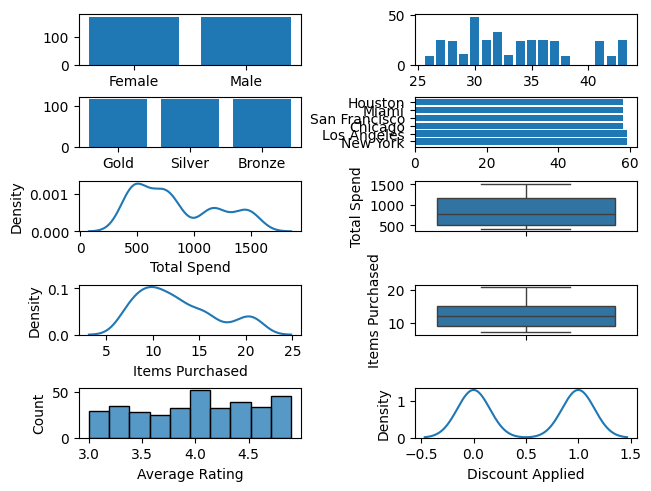

In [45]:
fig,ax = plt.subplots(nrows=5,ncols=2,layout='constrained')
ax[0][0].bar(gen.index,gen.values)
ax[0][1].bar(age.index,age.values)
ax[1][0].bar(mt.index,mt.values)
ax[1][1].barh(city.index,city.values)
sns.kdeplot(df['Total Spend'],ax=ax[2][0])
sns.boxplot(df['Total Spend'],ax=ax[2][1])
sns.kdeplot(df['Items Purchased'],ax=ax[3][0]) 
sns.boxplot(df['Items Purchased'],ax=ax[3][1])
sns.histplot(df['Average Rating'],ax=ax[4][0])
sns.kdeplot(df['Discount Applied'],ax=ax[4][1])